In [24]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import joblib


In [25]:
df = pd.read_csv("resultados_carga_normal.csv")

In [26]:
df = df[["timeStamp", "elapsed", "success"]]

# Converter tipos
df["timeStamp"] = pd.to_datetime(df["timeStamp"], unit="ms", errors="coerce")
df["elapsed"] = pd.to_numeric(df["elapsed"], errors="coerce")

# Converter success para numérico
df["success"] = df["success"].astype(str).str.lower().map({
    "true": 1,
    "false": 0
})

# Remover valores inválidos
df = df.dropna()


In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
# Extrair informação temporal
df["hour"] = df["timeStamp"].dt.hour
df["minute"] = df["timeStamp"].dt.minute

# Dataset final
X = df[["elapsed", "success", "hour", "minute"]]


In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
model = IsolationForest(
    n_estimators=150,
    contamination=0.01,  # assume poucos problemas no ambiente "normal"
    random_state=42
)

model.fit(X_scaled)

IsolationForest(contamination=0.01, n_estimators=150, random_state=42)

In [31]:

joblib.dump(model, "modelo_anomalia1.pkl")
joblib.dump(scaler, "scaler.pkl")

print("✅ Modelo salvo: modelo_anomalia.pkl")
print("✅ Scaler salvo: scaler.pkl")

✅ Modelo salvo: modelo_anomalia.pkl
✅ Scaler salvo: scaler.pkl


### 1. Gerando dados anômalos para simular uma sobrecarga

In [32]:
import numpy as np

# Gerar timestamps que seguem o mesmo padrão, mas com um deslocamento
anomaly_timestamps = pd.date_range(start='2026-04-22 22:45:30.000', periods=50, freq='2s')

# Simular tempos de resposta elevados (anomalia)
anomaly_elapsed = np.random.normal(loc=5000, scale=1000, size=50).astype(int)

# Simular algumas falhas (success=0)
anomaly_success = np.ones(50, dtype=int)
anomaly_success[:10] = 0  # Primeiras 10 requisições falharam
np.random.shuffle(anomaly_success) # Misturar para ter falhas em diferentes posições

anomaly_df = pd.DataFrame({
    'timeStamp': anomaly_timestamps,
    'elapsed': anomaly_elapsed,
    'success': anomaly_success,
    'label': ['normal'] * 50 # Adicionar uma coluna 'label' para os dados anômalos
})

# Simular alguns valores normais dentro do dataset anômalo para testar a detecção
normal_part_elapsed = np.random.normal(loc=1000, scale=100, size=10).astype(int)
normal_part_success = np.ones(10, dtype=int)
normal_part_timestamps = pd.date_range(start='2026-04-22 22:46:00.000', periods=10, freq='1s')

normal_part_df = pd.DataFrame({
    'timeStamp': normal_part_timestamps,
    'elapsed': normal_part_elapsed,
    'success': normal_part_success,
    'label': ['normal'] * 10
})

anomaly_df = pd.concat([anomaly_df, normal_part_df]).reset_index(drop=True)

# Salvar o dataset anômalo
anomaly_df.to_csv('resultados_carga_anomala.csv', index=False)

print("✅ Arquivo 'resultados_carga_anomala.csv' gerado com sucesso.")
display(anomaly_df.head())
display(anomaly_df.tail())

✅ Arquivo 'resultados_carga_anomala.csv' gerado com sucesso.


,timeStamp,elapsed,success,label
0,2026-04-22 22:45:30,4253,1,normal
1,2026-04-22 22:45:32,4856,1,normal
2,2026-04-22 22:45:34,5139,1,normal
3,2026-04-22 22:45:36,5831,1,normal
4,2026-04-22 22:45:38,5346,0,normal


,timeStamp,elapsed,success,label
55,2026-04-22 22:46:05,1026,1,normal
56,2026-04-22 22:46:06,954,1,normal
57,2026-04-22 22:46:07,1079,1,normal
58,2026-04-22 22:46:08,1161,1,normal
59,2026-04-22 22:46:09,844,1,normal


### 2. Avaliando o modelo com os dados de sobrecarga anômala

In [33]:
# Carregar o modelo e o scaler salvos
loaded_model = joblib.load('modelo_anomalia.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# Carregar o novo dataset anômalo
df_anomaly = pd.read_csv('resultados_carga_anomala.csv')

# Pré-processar o dataset anômalo da mesma forma que o dataset de treinamento
df_anomaly['timeStamp'] = pd.to_datetime(df_anomaly['timeStamp'])
df_anomaly['elapsed'] = pd.to_numeric(df_anomaly['elapsed'], errors='coerce')
df_anomaly['success'] = df_anomaly['success'].astype(str).str.lower().map({
    'true': 1,
    'false': 0,
    '1': 1,
    '0': 0
})

df_anomaly = df_anomaly.dropna()

df_anomaly['hour'] = df_anomaly['timeStamp'].dt.hour
df_anomaly['minute'] = df_anomaly['timeStamp'].dt.minute

X_anomaly = df_anomaly[['elapsed', 'success', 'hour', 'minute']]
X_anomaly_scaled = loaded_scaler.transform(X_anomaly)

# Prever anomalias usando o modelo carregado
df_anomaly['anomaly_score'] = loaded_model.decision_function(X_anomaly_scaled)
df_anomaly['is_anomaly'] = loaded_model.predict(X_anomaly_scaled)

# Traduzir a previsão: -1 para anomalia, 1 para normal
df_anomaly['is_anomaly'] = df_anomaly['is_anomaly'].map({-1: 'Anomaly', 1: 'Normal'})

print("✅ Previsões de anomalia geradas com sucesso para 'resultados_carga_anomala.csv'.")
display(df_anomaly.head())
display(df_anomaly['is_anomaly'].value_counts())

✅ Previsões de anomalia geradas com sucesso para 'resultados_carga_anomala.csv'.


,timeStamp,elapsed,success,label,hour,minute,anomaly_score,is_anomaly
0,2026-04-22 22:45:30,4253,1,normal,22,45,-0.181643,Anomaly
1,2026-04-22 22:45:32,4856,1,normal,22,45,-0.181643,Anomaly
2,2026-04-22 22:45:34,5139,1,normal,22,45,-0.181643,Anomaly
3,2026-04-22 22:45:36,5831,1,normal,22,45,-0.181643,Anomaly
4,2026-04-22 22:45:38,5346,0,normal,22,45,-0.181643,Anomaly


,count
is_anomaly,
Anomaly,50
Normal,10


### 3. Visualizando as anomalias detectadas

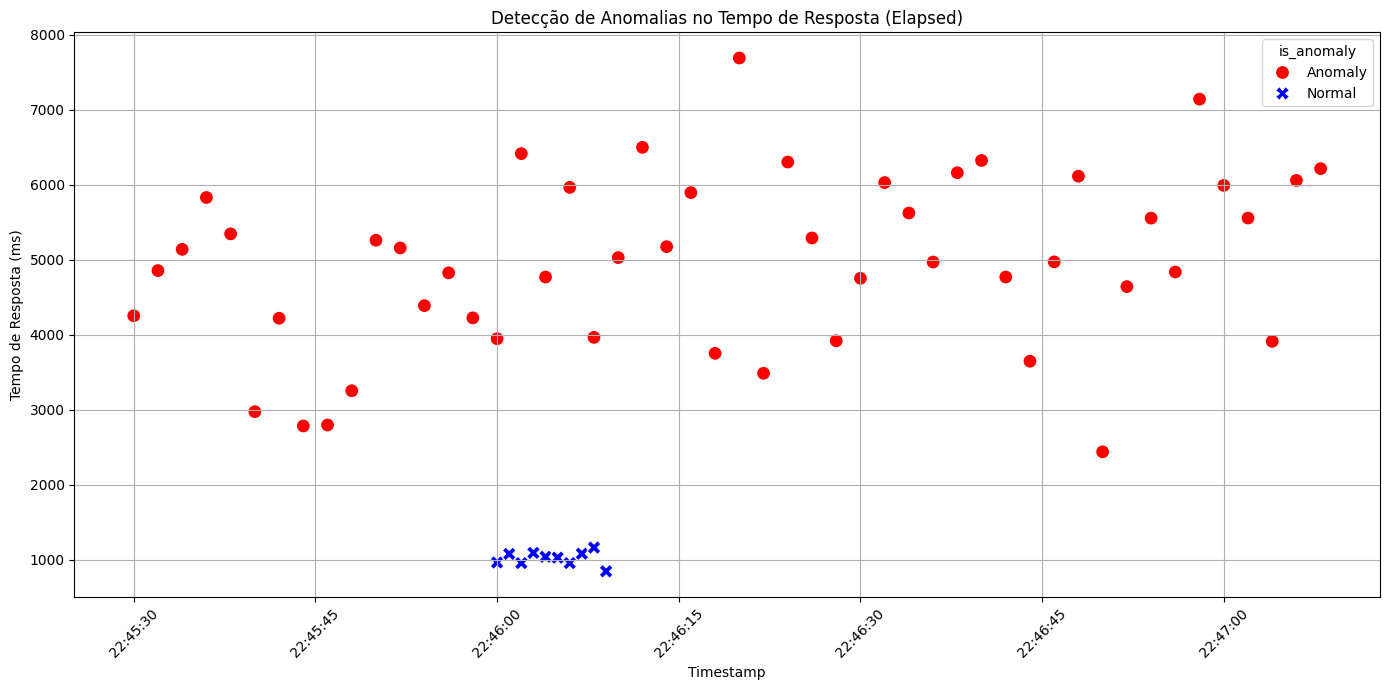

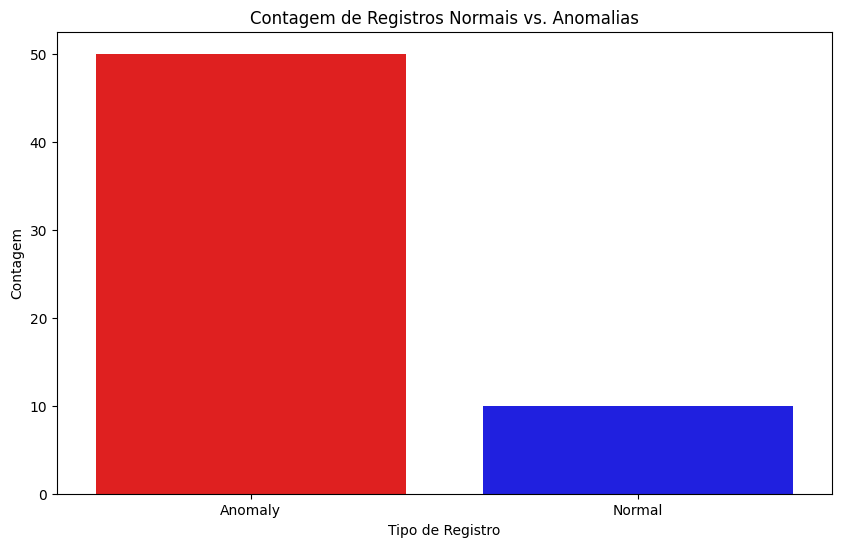

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.scatterplot(
    x=df_anomaly['timeStamp'],
    y=df_anomaly['elapsed'],
    hue=df_anomaly['is_anomaly'],
    style=df_anomaly['is_anomaly'],
    palette={'Normal': 'blue', 'Anomaly': 'red'},
    s=100
)
plt.title('Detecção de Anomalias no Tempo de Resposta (Elapsed)')
plt.xlabel('Timestamp')
plt.ylabel('Tempo de Resposta (ms)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(
    x=df_anomaly['is_anomaly'],
    hue=df_anomaly['is_anomaly'], # Added hue parameter
    palette={'Normal': 'blue', 'Anomaly': 'red'},
    legend=False # Added legend=False as suggested by warning
)
plt.title('Contagem de Registros Normais vs. Anomalias')
plt.xlabel('Tipo de Registro')
plt.ylabel('Contagem')
plt.show()